# 06 — Handcrafted Feature Ablation Study
## GTZAN Music Genre Classification

This experiment studies **which handcrafted audio feature groups contribute to genre classification**.

The experiment uses the existing leakage-aware `train / validation / test` assignments from `handcrafted_features.csv`.

### Important rules

- No new data split is created.
- The **test set is not used** for feature-group selection.
- Each feature configuration is trained using the same selected classical ML model.
- Validation Macro F1 is the primary comparison metric.
- The final held-out test evaluation belongs to Notebook 07.

In [18]:
# =========================
# 1. Install dependencies
# =========================
import sys
import subprocess
import importlib.util

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

missing = [
    pkg for module, pkg in required.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + missing
    )

print("Dependencies ready.")

Dependencies ready.


In [19]:
# =========================
# 2. Imports
# =========================
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Locate `handcrafted_features.csv`

In [20]:
# =========================
# 3. Locate feature CSV
# =========================
candidate_paths = [
    Path("/content/handcrafted_output/handcrafted_features.csv"),
    Path("/content/handcrafted_features.csv"),
    Path("handcrafted_output/handcrafted_features.csv"),
    Path("data/processed/handcrafted_features.csv"),
    Path("data/handcrafted_features.csv"),
    Path("handcrafted_features.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is None:
    try:
        from google.colab import files

        print("handcrafted_features.csv was not found.")
        print("Upload the CSV generated by Notebook 03.")
        uploaded = files.upload()

        if "handcrafted_features.csv" in uploaded:
            csv_path = Path("/content/handcrafted_features.csv")
        elif uploaded:
            first_name = next(iter(uploaded))
            csv_path = Path("/content") / first_name
    except ImportError:
        pass

if csv_path is None or not csv_path.exists():
    raise FileNotFoundError(
        "Could not find handcrafted_features.csv."
    )

print("Using:", csv_path.resolve())

Using: /content/handcrafted_features.csv


In [21]:
# =========================
# 4. Load and validate
# =========================
df = pd.read_csv(csv_path)

required_columns = {"relative_path", "genre", "split"}
missing = required_columns - set(df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")

feature_columns = [
    c for c in df.columns
    if c not in ["relative_path", "genre", "split"]
]

if len(feature_columns) != 137:
    raise ValueError(
        f"Expected 137 numeric features, found {len(feature_columns)}."
    )

if df[feature_columns].isnull().any().any():
    raise ValueError("Missing feature values detected.")

print("Dataset shape:", df.shape)
print("Feature count:", len(feature_columns))
print("\nSplit counts:")
print(df["split"].value_counts().sort_index())

Dataset shape: (1000, 140)
Feature count: 137

Split counts:
split
test          150
train         700
validation    150
Name: count, dtype: int64


# 5. Build the fixed train / validation / test partitions

The split is taken directly from the existing `split` column.

No random splitting is performed.

In [22]:
# =========================
# 5. Existing split
# =========================
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

assert len(train_df) == 700
assert len(val_df) == 150
assert len(test_df) == 150

assert set(train_df["relative_path"]).isdisjoint(
    val_df["relative_path"]
)
assert set(train_df["relative_path"]).isdisjoint(
    test_df["relative_path"]
)
assert set(val_df["relative_path"]).isdisjoint(
    test_df["relative_path"]
)

y_train = train_df["genre"].astype(str)
y_val = val_df["genre"].astype(str)
y_test = test_df["genre"].astype(str)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Leakage checks passed.")

Train: 700
Validation: 150
Test: 150
Leakage checks passed.


# 6. Define feature groups

The 137 features are grouped according to how they were extracted in Notebook 03.

### Groups

- **MFCC** — 26 features
- **Delta MFCC** — 26 features
- **Delta² MFCC** — 26 features
- **Chroma** — 24 features
- **Spectral** — 28 features
- **Rhythm / Energy** — 7 features

Total:

```text
26 + 26 + 26 + 24 + 28 + 7 = 137
```

The spectral group includes centroid, bandwidth, rolloff, contrast, flatness, flux, entropy, skewness, and kurtosis.

In [23]:
# =========================
# 6. Feature group definitions
# =========================
groups = {
    "MFCC": [
        c for c in feature_columns
        if c.startswith("mfcc_")
    ],

    "Delta MFCC": [
        c for c in feature_columns
        if c.startswith("delta_mfcc_")
    ],

    "Delta2 MFCC": [
        c for c in feature_columns
        if c.startswith("delta2_mfcc_")
    ],

    "Chroma": [
        c for c in feature_columns
        if c.startswith("chroma_")
    ],

    "Spectral": [
        c for c in feature_columns
        if (
            c.startswith("spectral_centroid_")
            or c.startswith("spectral_bandwidth_")
            or c.startswith("spectral_rolloff_")
            or c.startswith("spectral_contrast_")
            or c.startswith("spectral_flatness_")
            or c.startswith("spectral_flux_")
            or c.startswith("spectral_entropy_")
            or c.startswith("spectral_skewness_")
            or c.startswith("spectral_kurtosis_")
        )
    ],

    "Rhythm / Energy": [
        c for c in feature_columns
        if (
            c.startswith("rms_")
            or c.startswith("zcr_")
            or c == "tempo"
        )
    ],
}

for name, cols in groups.items():
    print(f"{name:18s}: {len(cols)} features")

assert sum(len(v) for v in groups.values()) == 137

print("\nAll 137 features are assigned exactly once.")

MFCC              : 26 features
Delta MFCC        : 26 features
Delta2 MFCC       : 26 features
Chroma            : 24 features
Spectral          : 30 features
Rhythm / Energy   : 5 features

All 137 features are assigned exactly once.


# 7. Define cumulative feature configurations

We evaluate progressively richer representations:

1. MFCC
2. MFCC + Delta
3. MFCC + Delta + Delta²
4. Previous + Chroma
5. Previous + Spectral
6. Previous + Rhythm / Energy

This lets us measure the incremental contribution of each feature family.

In [24]:
# =========================
# 7. Cumulative ablation configurations
# =========================
cumulative_configs = {
    "A — MFCC": [
        "MFCC"
    ],

    "B — MFCC + Delta": [
        "MFCC",
        "Delta MFCC"
    ],

    "C — MFCC + Delta + Delta2": [
        "MFCC",
        "Delta MFCC",
        "Delta2 MFCC"
    ],

    "D — + Chroma": [
        "MFCC",
        "Delta MFCC",
        "Delta2 MFCC",
        "Chroma"
    ],

    "E — + Spectral": [
        "MFCC",
        "Delta MFCC",
        "Delta2 MFCC",
        "Chroma",
        "Spectral"
    ],

    "F — ALL 137": [
        "MFCC",
        "Delta MFCC",
        "Delta2 MFCC",
        "Chroma",
        "Spectral",
        "Rhythm / Energy"
    ],
}

config_feature_columns = {}

for config_name, selected_groups in cumulative_configs.items():
    selected = []
    for group_name in selected_groups:
        selected.extend(groups[group_name])

    # Preserve original CSV feature order.
    selected = [c for c in feature_columns if c in set(selected)]

    config_feature_columns[config_name] = selected

    print(f"{config_name:30s}: {len(selected)} features")

assert len(config_feature_columns["F — ALL 137"]) == 137

A — MFCC                      : 26 features
B — MFCC + Delta              : 52 features
C — MFCC + Delta + Delta2     : 78 features
D — + Chroma                  : 102 features
E — + Spectral                : 132 features
F — ALL 137                   : 137 features


# 8. Choose the classical model for ablation

Feature ablation should isolate the **representation effect**, not compare different algorithms at the same time.

The default model below is a strong and stable classical baseline:

**StandardScaler → RBF SVM**

The hyperparameters are fixed during this experiment.

If Notebook 05 identifies a different best tuned model, you can later replace this configuration with that model. The important rule is to keep the **same model configuration across all ablation experiments**.

In [25]:
# =========================
# 8. Fixed model for ablation
# =========================
ABLATION_MODEL = "SVM"

def build_ablation_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            C=10,
            gamma=0.001,
            random_state=RANDOM_STATE
        ))
    ])

    raise ValueError(
        "Unsupported ABLATION_MODEL. "
        "Keep it as SVM unless you intentionally change the experiment."
    )

print("Ablation model:", ABLATION_MODEL)

Ablation model: SVM


In [26]:
# =========================
# 9. Evaluation function
# =========================
def evaluate_features(feature_cols):
    X_train = train_df[feature_cols].astype(np.float32)
    X_val = val_df[feature_cols].astype(np.float32)

    model = build_ablation_model()

    start = time.time()
    model.fit(X_train, y_train)
    predictions = model.predict(X_val)
    elapsed = time.time() - start

    return {
        "accuracy": accuracy_score(y_val, predictions),
        "macro_precision": precision_score(
            y_val, predictions,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            y_val, predictions,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            y_val, predictions,
            average="macro",
            zero_division=0
        ),
        "weighted_f1": f1_score(
            y_val, predictions,
            average="weighted",
            zero_division=0
        ),
        "n_features": len(feature_cols),
        "training_seconds": elapsed,
    }

# 10. Run cumulative ablation experiments

In [27]:
# =========================
# 10. Run ablation
# =========================
ablation_results = []

for config_name, feature_cols in config_feature_columns.items():
    print("=" * 75)
    print(config_name)
    print("Features:", len(feature_cols))

    metrics = evaluate_features(feature_cols)
    metrics["configuration"] = config_name

    ablation_results.append(metrics)

    print(f"Accuracy        : {metrics['accuracy']:.4f}")
    print(f"Macro Precision : {metrics['macro_precision']:.4f}")
    print(f"Macro Recall    : {metrics['macro_recall']:.4f}")
    print(f"Macro F1        : {metrics['macro_f1']:.4f}")
    print(f"Weighted F1     : {metrics['weighted_f1']:.4f}")

ablation_df = pd.DataFrame(ablation_results)

ablation_df = ablation_df[
    [
        "configuration",
        "n_features",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "training_seconds",
    ]
]

print("\nAblation results:")
display(
    ablation_df.style.format({
        "accuracy": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}",
        "training_seconds": "{:.2f}",
    })
)

A — MFCC
Features: 26
Accuracy        : 0.6067
Macro Precision : 0.6016
Macro Recall    : 0.6067
Macro F1        : 0.5949
Weighted F1     : 0.5949
B — MFCC + Delta
Features: 52
Accuracy        : 0.6333
Macro Precision : 0.6240
Macro Recall    : 0.6333
Macro F1        : 0.6193
Weighted F1     : 0.6193
C — MFCC + Delta + Delta2
Features: 78
Accuracy        : 0.6533
Macro Precision : 0.6585
Macro Recall    : 0.6533
Macro F1        : 0.6505
Weighted F1     : 0.6505
D — + Chroma
Features: 102
Accuracy        : 0.6800
Macro Precision : 0.6804
Macro Recall    : 0.6800
Macro F1        : 0.6771
Weighted F1     : 0.6771
E — + Spectral
Features: 132
Accuracy        : 0.7667
Macro Precision : 0.7722
Macro Recall    : 0.7667
Macro F1        : 0.7650
Weighted F1     : 0.7650
F — ALL 137
Features: 137
Accuracy        : 0.8000
Macro Precision : 0.8051
Macro Recall    : 0.8000
Macro F1        : 0.7974
Weighted F1     : 0.7974

Ablation results:


,configuration,n_features,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_seconds
0,A — MFCC,26,0.6067,0.6016,0.6067,0.5949,0.5949,0.16
1,B — MFCC + Delta,52,0.6333,0.6240,0.6333,0.6193,0.6193,0.17
2,C — MFCC + Delta + Delta2,78,0.6533,0.6585,0.6533,0.6505,0.6505,0.24
3,D — + Chroma,102,0.6800,0.6804,0.6800,0.6771,0.6771,0.20
4,E — + Spectral,132,0.7667,0.7722,0.7667,0.7650,0.7650,0.34
5,F — ALL 137,137,0.8000,0.8051,0.8000,0.7974,0.7974,0.20


# 11. Measure incremental contribution

For each stage, calculate the change in validation Macro F1 compared with the previous configuration.

This is useful for the report because it shows which added feature family helps most.

In [28]:
# =========================
# 11. Incremental Macro F1
# =========================
ablation_df["macro_f1_change"] = (
    ablation_df["macro_f1"].diff()
)

print("Incremental Macro F1 contribution:")
display(
    ablation_df[
        [
            "configuration",
            "n_features",
            "macro_f1",
            "macro_f1_change"
        ]
    ].style.format({
        "macro_f1": "{:.4f}",
        "macro_f1_change": "{:+.4f}",
    })
)

Incremental Macro F1 contribution:


,configuration,n_features,macro_f1,macro_f1_change
0,A — MFCC,26,0.5949,+nan
1,B — MFCC + Delta,52,0.6193,+0.0244
2,C — MFCC + Delta + Delta2,78,0.6505,+0.0311
3,D — + Chroma,102,0.6771,+0.0266
4,E — + Spectral,132,0.7650,+0.0879
5,F — ALL 137,137,0.7974,+0.0324


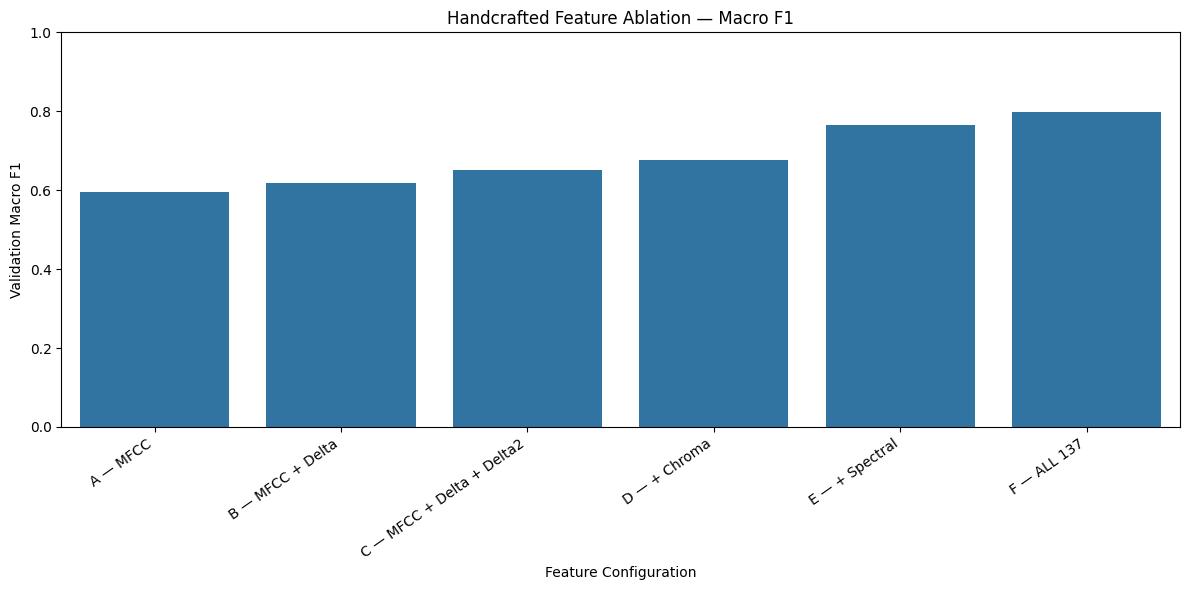

In [29]:
# =========================
# 12. Plot Macro F1
# =========================
plt.figure(figsize=(12, 6))

sns.barplot(
    data=ablation_df,
    x="configuration",
    y="macro_f1"
)

plt.ylim(0, 1)
plt.xlabel("Feature Configuration")
plt.ylabel("Validation Macro F1")
plt.title("Handcrafted Feature Ablation — Macro F1")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

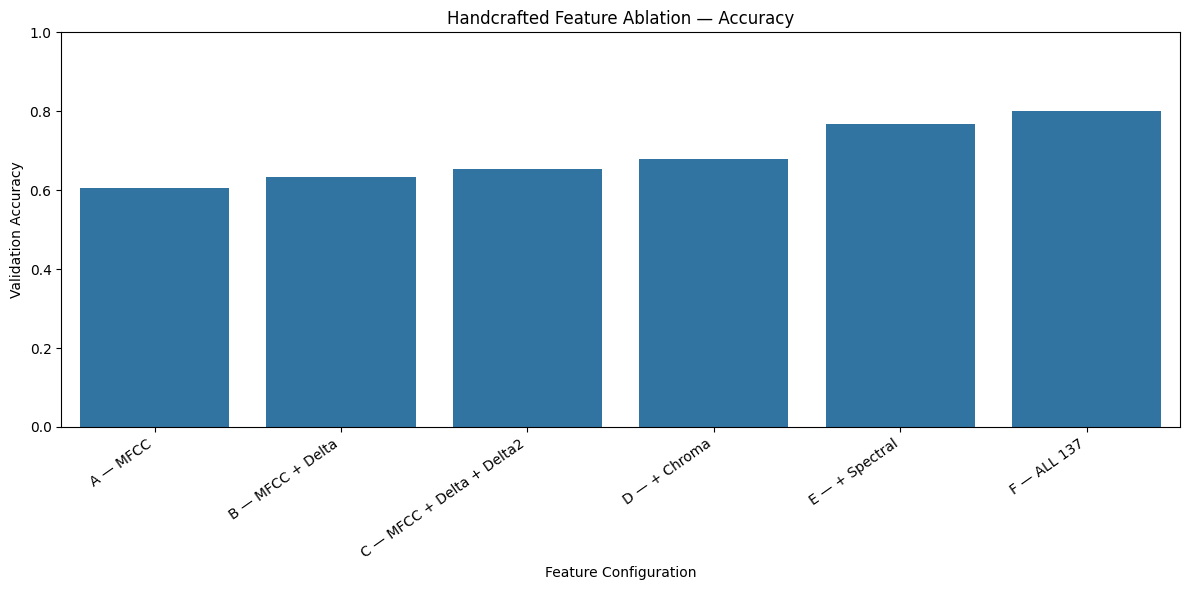

In [30]:
# =========================
# 13. Plot accuracy
# =========================
plt.figure(figsize=(12, 6))

sns.barplot(
    data=ablation_df,
    x="configuration",
    y="accuracy"
)

plt.ylim(0, 1)
plt.xlabel("Feature Configuration")
plt.ylabel("Validation Accuracy")
plt.title("Handcrafted Feature Ablation — Accuracy")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# 14. Identify the best feature configuration

The best representation is selected using validation Macro F1.

The test set is still untouched.

In [31]:
# =========================
# 14. Best feature configuration
# =========================
best_ablation = (
    ablation_df
    .sort_values("macro_f1", ascending=False)
    .iloc[0]
)

best_config_name = best_ablation["configuration"]
best_config_f1 = float(best_ablation["macro_f1"])

print("=" * 75)
print("BEST FEATURE CONFIGURATION")
print("=" * 75)
print("Configuration:", best_config_name)
print("Number of features:", int(best_ablation["n_features"]))
print(f"Validation Macro F1: {best_config_f1:.4f}")

print("\nFeature groups:")
for group_name in cumulative_configs[best_config_name]:
    print(" -", group_name)

BEST FEATURE CONFIGURATION
Configuration: F — ALL 137
Number of features: 137
Validation Macro F1: 0.7974

Feature groups:
 - MFCC
 - Delta MFCC
 - Delta2 MFCC
 - Chroma
 - Spectral
 - Rhythm / Energy


# 15. Save ablation results

In [32]:
# =========================
# 15. Save outputs
# =========================
results_dir = Path("results")
tables_dir = results_dir / "tables"
figures_dir = results_dir / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

ablation_df.to_csv(
    tables_dir / "handcrafted_feature_ablation_results.csv",
    index=False
)

best_ablation.to_frame().T.to_csv(
    tables_dir / "best_handcrafted_feature_configuration.csv",
    index=False
)

metadata = {
    "project": "Music Genre Classification",
    "dataset": "GTZAN",
    "experiment": "Handcrafted Feature Ablation",
    "model": ABLATION_MODEL,
    "selection_metric": "validation_macro_f1",
    "test_used_for_selection": False,
    "best_configuration": str(best_config_name),
    "best_validation_macro_f1": best_config_f1,
    "best_feature_count": int(best_ablation["n_features"]),
    "feature_groups": cumulative_configs[best_config_name],
    "random_state": RANDOM_STATE,
}

with open(
    results_dir / "feature_ablation_config.json",
    "w"
) as f:
    import json
    json.dump(metadata, f, indent=2)

print("Saved:")
print(tables_dir / "handcrafted_feature_ablation_results.csv")
print(tables_dir / "best_handcrafted_feature_configuration.csv")
print(results_dir / "feature_ablation_config.json")

Saved:
results/tables/handcrafted_feature_ablation_results.csv
results/tables/best_handcrafted_feature_configuration.csv
results/feature_ablation_config.json


# 16. Final summary

This experiment answers:

> Which handcrafted acoustic feature groups contribute most to music genre classification?

### Important

Do **not** report the test performance from this notebook.

The selected feature configuration will be carried into Notebook 07, where the final model will be trained on **train + validation** and evaluated once on the held-out test set.

In [33]:
# =========================
# 16. Final summary
# =========================
print("=" * 80)
print("FEATURE ABLATION — FINAL SUMMARY")
print("=" * 80)

print(f"Model used              : {ABLATION_MODEL}")
print(f"Feature configurations  : {len(ablation_df)}")
print(f"Best configuration      : {best_config_name}")
print(f"Best feature count      : {int(best_ablation['n_features'])}")
print(f"Best validation Macro F1: {best_config_f1:.4f}")

print("\nThe test set was NOT used for feature selection.")
print("=" * 80)

FEATURE ABLATION — FINAL SUMMARY
Model used              : SVM
Feature configurations  : 6
Best configuration      : F — ALL 137
Best feature count      : 137
Best validation Macro F1: 0.7974

The test set was NOT used for feature selection.
